In [1]:
!pip install imblearn seaborn xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time as tm
import joblib




#skit learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import  classification_report, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from imblearn import under_sampling, over_sampling
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline


pd.set_option('display.max_columns', 140)
pd.set_option('display.max_rows', 140)
warnings.filterwarnings('ignore')


[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: C:\Users\gerem\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [45]:
df_flights = pd.read_csv(r"C:\Users\gerem\Desktop\Tech_challenge_3_M_Supervisionados_N_Supervisionados\data\flights.csv")

In [46]:
df_flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
condicoes = [
    df_flights['ARRIVAL_DELAY'] > 0,
    df_flights['ARRIVAL_DELAY'] <= 0
]

valores = ['atrasado', 'pontual']

df_flights['status_voo'] = np.select(condicoes, valores, default='pontual')


In [48]:
df_flights['ORIGIN_AIRPORT'].map(type).value_counts()

ORIGIN_AIRPORT
<class 'str'>    5360327
<class 'int'>     458752
Name: count, dtype: int64

In [49]:
df_flights[
    df_flights['DESTINATION_AIRPORT'].map(lambda x: isinstance(x, int))
]['DESTINATION_AIRPORT'].sort_values(ascending = False).unique()

array([16218, 15991, 15919, 15841, 15624, 15607, 15497, 15412, 15411,
       15401, 15389, 15380, 15376, 15370, 15356, 15323, 15304, 15295,
       15249, 15096, 15070, 15048, 15041, 15027, 15024, 15016, 14986,
       14960, 14952, 14908, 14905, 14893, 14869, 14843, 14842, 14831,
       14828, 14814, 14794, 14783, 14771, 14747, 14730, 14711, 14709,
       14698, 14696, 14689, 14685, 14683, 14679, 14674, 14635, 14633,
       14588, 14576, 14574, 14570, 14543, 14524, 14520, 14492, 14489,
       14487, 14457, 14321, 14307, 14262, 14256, 14254, 14252, 14222,
       14193, 14150, 14122, 14113, 14109, 14108, 14107, 14100, 14098,
       14057, 14027, 14025, 14006, 13970, 13964, 13933, 13931, 13930,
       13891, 13873, 13871, 13851, 13830, 13796, 13795, 13577, 13541,
       13502, 13495, 13487, 13486, 13485, 13476, 13459, 13433, 13422,
       13377, 13367, 13360, 13344, 13342, 13303, 13296, 13290, 13277,
       13264, 13256, 13244, 13241, 13232, 13230, 13204, 13198, 13184,
       13158, 13127,

In [50]:
df_flights['DESTINATION_AIRPORT'].map(type).value_counts()



DESTINATION_AIRPORT
<class 'str'>    5360327
<class 'int'>     458752
Name: count, dtype: int64

In [51]:
df_flights.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'status_voo'],
      dtype='object')

In [52]:

(df_flights.isna().sum() / df_flights.shape[0] * 100).sort_values(ascending = False)

CANCELLATION_REASON    98.455357
SECURITY_DELAY         81.724960
WEATHER_DELAY          81.724960
LATE_AIRCRAFT_DELAY    81.724960
AIRLINE_DELAY          81.724960
AIR_SYSTEM_DELAY       81.724960
ELAPSED_TIME            1.805629
AIR_TIME                1.805629
ARRIVAL_DELAY           1.805629
ARRIVAL_TIME            1.589822
TAXI_IN                 1.589822
WHEELS_ON               1.589822
WHEELS_OFF              1.530259
TAXI_OUT                1.530259
DEPARTURE_TIME          1.480526
DEPARTURE_DELAY         1.480526
TAIL_NUMBER             0.252978
SCHEDULED_TIME          0.000103
SCHEDULED_DEPARTURE     0.000000
MONTH                   0.000000
DAY_OF_WEEK             0.000000
AIRLINE                 0.000000
FLIGHT_NUMBER           0.000000
ORIGIN_AIRPORT          0.000000
YEAR                    0.000000
DESTINATION_AIRPORT     0.000000
DAY                     0.000000
DISTANCE                0.000000
DIVERTED                0.000000
SCHEDULED_ARRIVAL       0.000000
CANCELLED 

In [53]:
df_flights.shape


(5819079, 32)

In [54]:
df_flights = df_flights.drop(columns=['CANCELLATION_REASON', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'AIRLINE_DELAY', 
                                      'AIR_SYSTEM_DELAY', 'SECURITY_DELAY'])

In [55]:
cols_num = [
    'ELAPSED_TIME','AIR_TIME', 'ARRIVAL_DELAY',
    'TAXI_IN', 'TAXI_OUT',
    'DEPARTURE_DELAY', 'SCHEDULED_TIME', 'WHEELS_ON', 'WHEELS_OFF', 'DEPARTURE_TIME','ARRIVAL_TIME'
]

df_flights[cols_num] = df_flights[cols_num].apply(
    lambda col: col.fillna(col.median())
)


In [56]:
df_flights.shape

(5819079, 26)

In [57]:
colunas_traduzidas = {
    'YEAR': 'ano',
    'MONTH': 'mes',
    'DAY': 'dia',
    'DAY_OF_WEEK': 'dia_da_semana',
    'AIRLINE': 'companhia_aerea',
    'FLIGHT_NUMBER': 'numero_voo',
    'TAIL_NUMBER': 'matricula_aeronave',
    'ORIGIN_AIRPORT': 'aeroporto_origem',
    'DESTINATION_AIRPORT': 'aeroporto_destino',
    'SCHEDULED_DEPARTURE': 'partida_programada',
    'DEPARTURE_TIME': 'horario_partida_real',
    'DEPARTURE_DELAY': 'atraso_partida',
    'TAXI_OUT': 'tempo_taxi_saida',
    'WHEELS_OFF': 'decolagem_real',
    'SCHEDULED_TIME': 'tempo_programado_voo',
    'ELAPSED_TIME': 'tempo_total_voo',
    'AIR_TIME': 'tempo_no_ar',
    'DISTANCE': 'distancia',
    'WHEELS_ON': 'pouso_real',
    'TAXI_IN': 'tempo_taxi_chegada',
    'SCHEDULED_ARRIVAL': 'chegada_programada',
    'ARRIVAL_TIME': 'horario_chegada_real',
    'ARRIVAL_DELAY': 'atraso_chegada',
    'DIVERTED': 'voo_desviado',
    'CANCELLED': 'voo_cancelado'
}


In [58]:
df_flights.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,status_voo
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,pontual
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,pontual
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,atrasado
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,pontual
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,pontual


In [59]:
df_flights = df_flights.rename(columns=colunas_traduzidas)

In [60]:


cols = [
    'tempo_taxi_saida',
    'tempo_programado_voo',
    'tempo_total_voo',
    'tempo_no_ar',
    'distancia',
    'tempo_taxi_chegada'
]

for col in cols:
    lower = df_flights[col].quantile(0.01)
    upper = df_flights[col].quantile(0.99)
    
    df_flights[col] = np.clip(df_flights[col], lower, upper)

<Axes: xlabel='tempo_total_voo', ylabel='Count'>

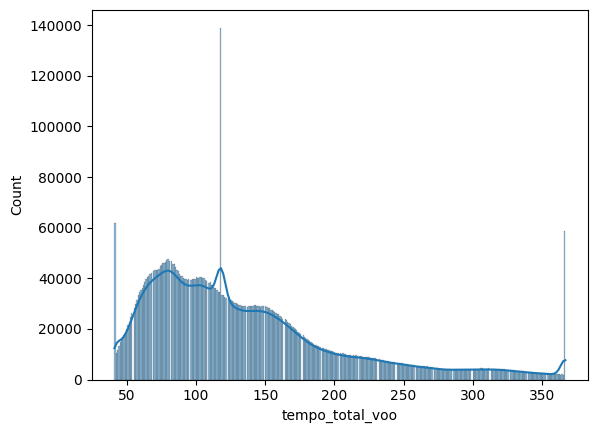

In [61]:
import seaborn as sns
sns.histplot(df_flights['tempo_total_voo'], kde=True)

In [62]:

df_flights["velocidade_media"] = df_flights["distancia"] / df_flights["tempo_programado_voo"]

In [63]:
df_flights[['partida_programada','horario_partida_real', 'atraso_partida']]

,partida_programada,horario_partida_real,atraso_partida
0,5,2354.0,-11.0
1,10,2.0,-8.0
2,20,18.0,-2.0
3,20,15.0,-5.0
4,25,24.0,-1.0
...,...,...,...
5819074,2359,2355.0,-4.0
5819075,2359,2355.0,-4.0
5819076,2359,2350.0,-9.0
5819077,2359,2353.0,-6.0


In [64]:
df_flights.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ano,5819079.0,2015.000000,0.000000,2015.000000,2015.000000,2015.000000,2015.000000,2015.000000
mes,5819079.0,6.524085,3.405137,1.000000,4.000000,7.000000,9.000000,12.000000
dia,5819079.0,15.704594,8.783425,1.000000,8.000000,16.000000,23.000000,31.000000
dia_da_semana,5819079.0,3.926941,1.988845,1.000000,2.000000,4.000000,6.000000,7.000000
numero_voo,5819079.0,2173.092742,1757.063999,1.000000,730.000000,1690.000000,3230.000000,9855.000000
partida_programada,5819079.0,1329.602470,483.751821,1.000000,917.000000,1325.000000,1730.000000,2359.000000
horario_partida_real,5819079.0,1335.127386,492.735118,1.000000,925.000000,1330.000000,1736.000000,2400.000000
atraso_partida,5819079.0,9.201820,36.831030,-82.000000,-5.000000,-2.000000,7.000000,1988.000000
tempo_taxi_saida,5819079.0,15.879835,7.757193,6.000000,11.000000,14.000000,19.000000,50.000000
decolagem_real,5819079.0,1356.953991,494.187310,1.000000,939.000000,1343.000000,1750.000000,2400.000000


In [65]:
df_flights.dtypes

ano                       int64
mes                       int64
dia                       int64
dia_da_semana             int64
companhia_aerea          object
numero_voo                int64
matricula_aeronave       object
aeroporto_origem         object
aeroporto_destino        object
partida_programada        int64
horario_partida_real    float64
atraso_partida          float64
tempo_taxi_saida        float64
decolagem_real          float64
tempo_programado_voo    float64
tempo_total_voo         float64
tempo_no_ar             float64
distancia                 int64
pouso_real              float64
tempo_taxi_chegada      float64
chegada_programada        int64
horario_chegada_real    float64
atraso_chegada          float64
voo_desviado              int64
voo_cancelado             int64
status_voo               object
velocidade_media        float64
dtype: object

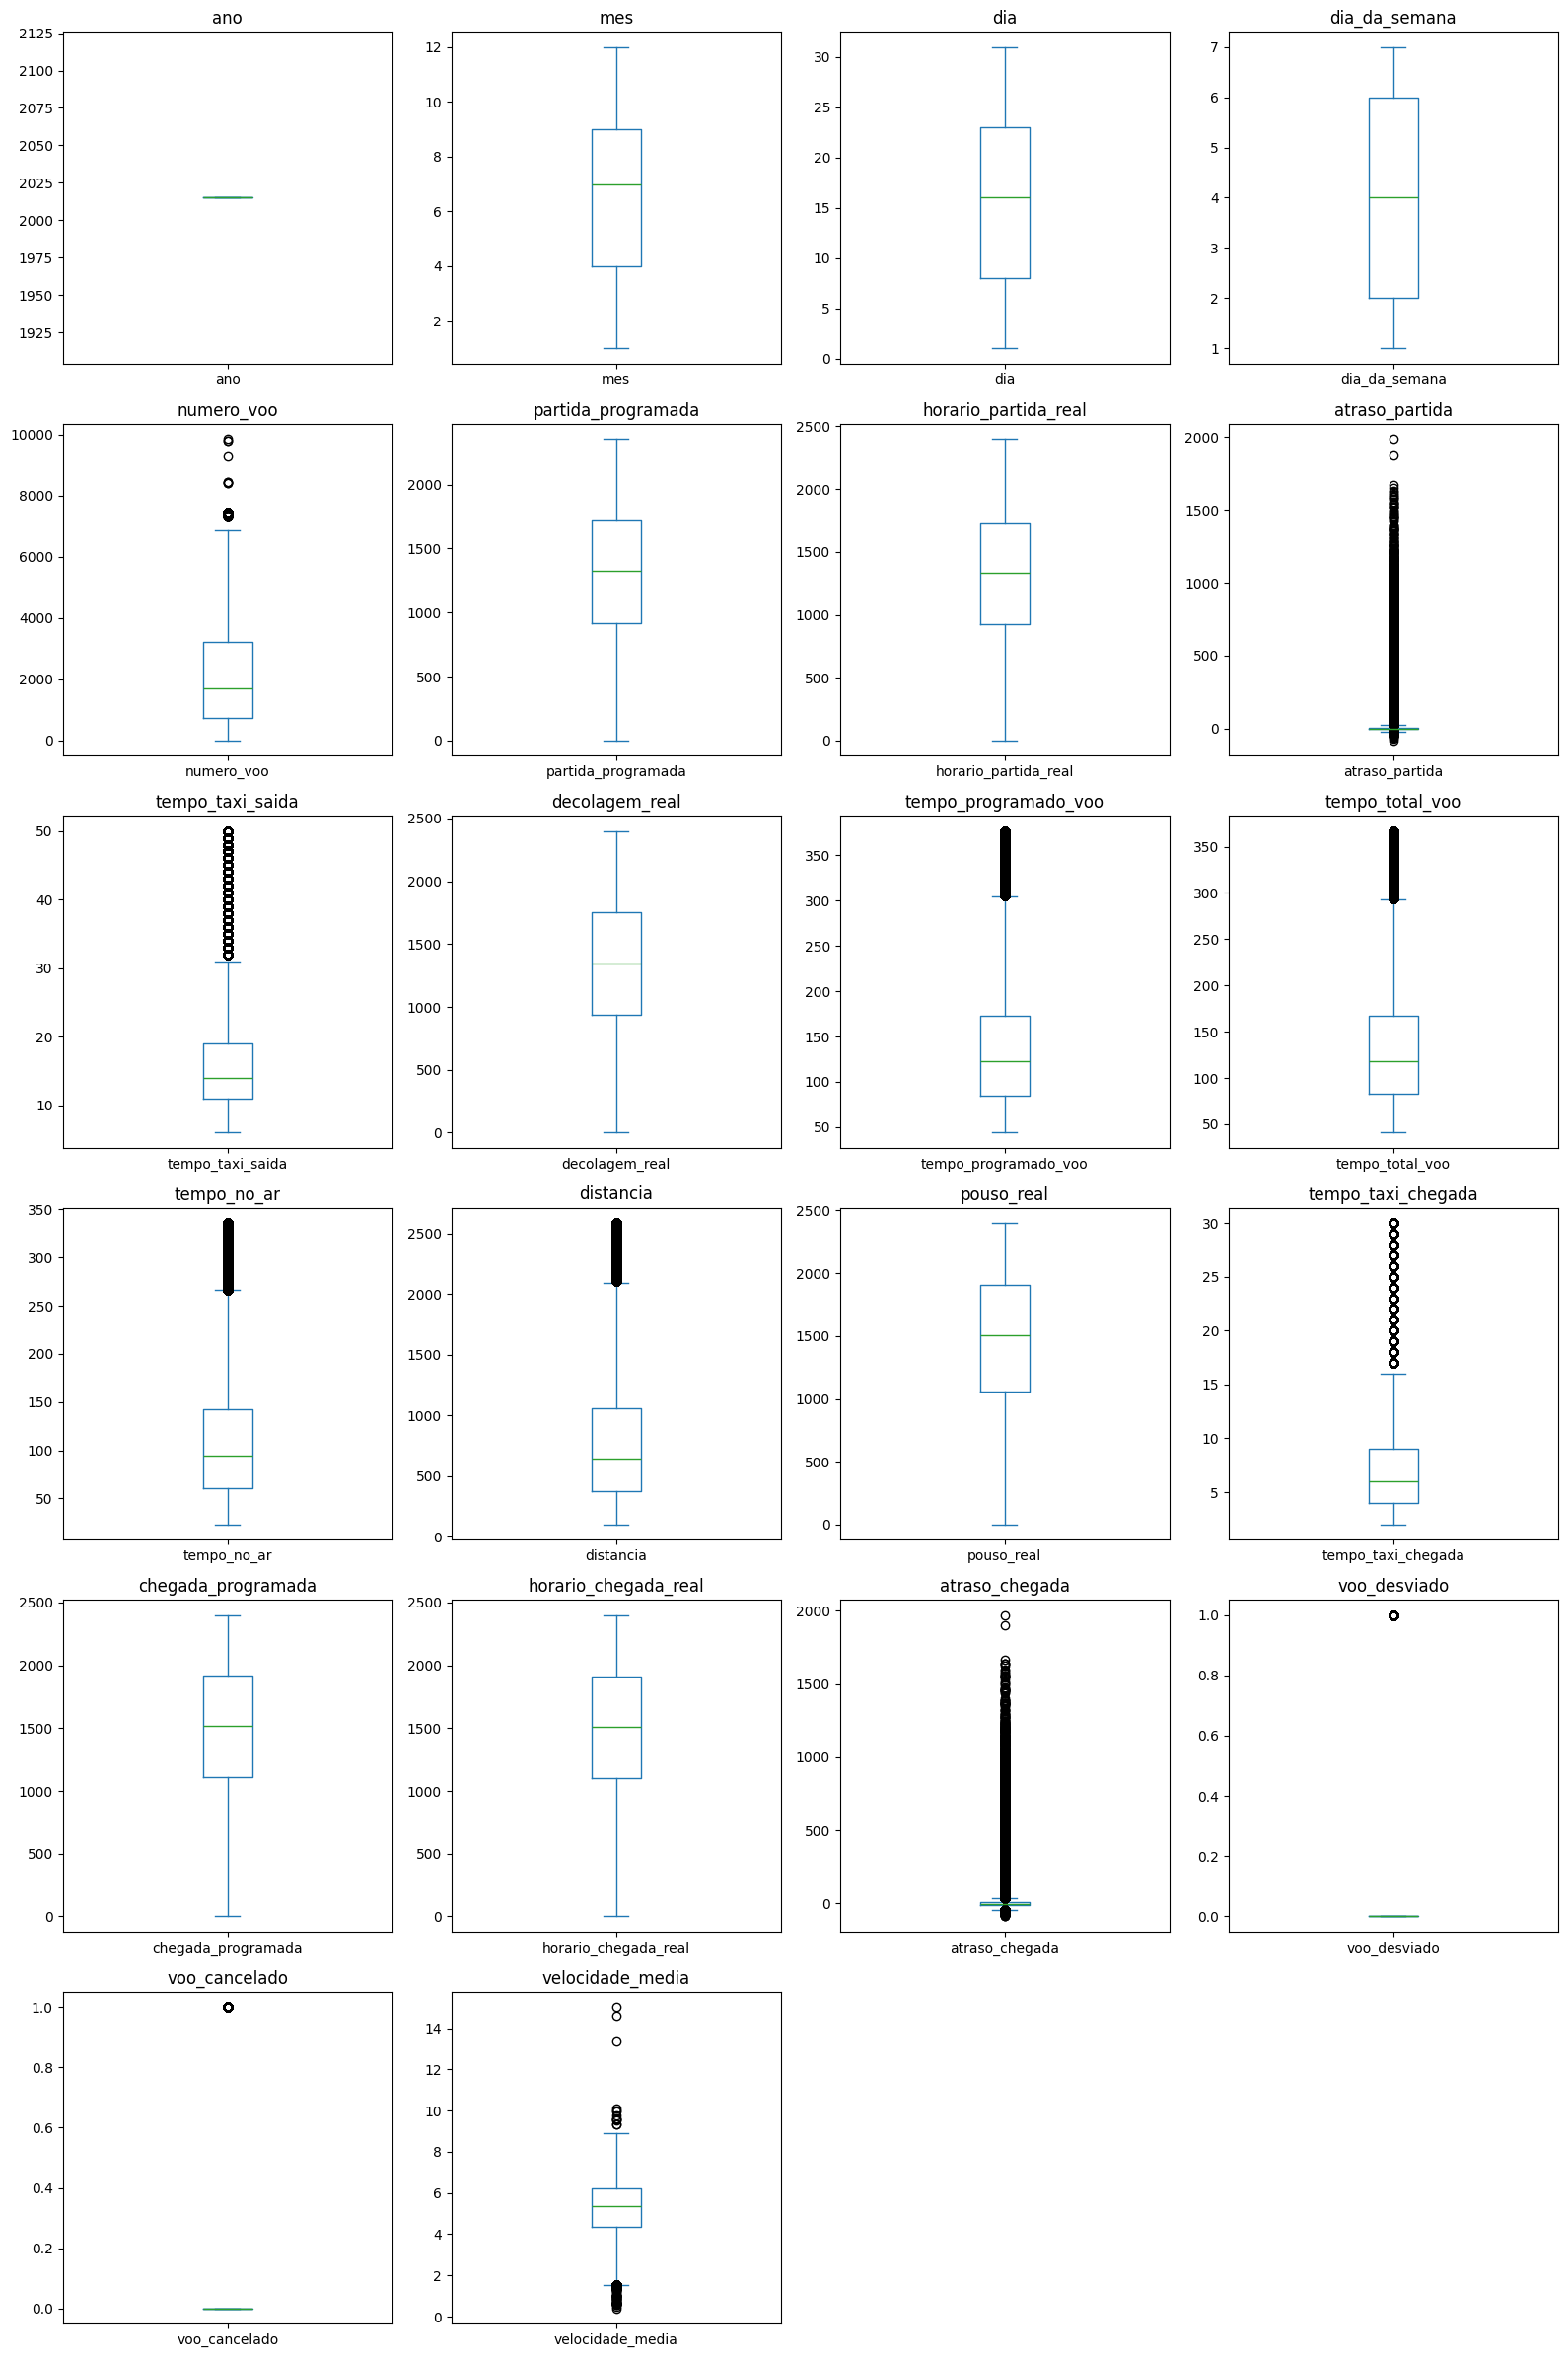

In [66]:


cols = df_flights.select_dtypes(include='number').columns

ncols = 4
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    df_flights[col].plot(kind='box', ax=ax)
    ax.set_title(col)

# remove gráficos vazios
for ax in axes[len(cols):]:
    ax.remove()

plt.tight_layout()
plt.show()


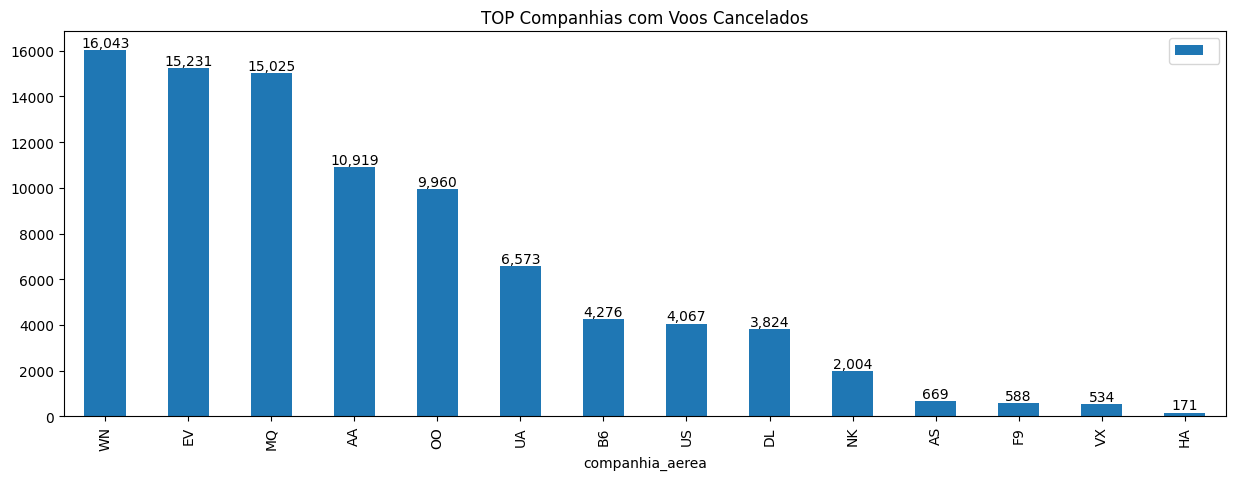

In [67]:
voos_cancelado = df_flights[df_flights['voo_cancelado'] == 1]

ax = voos_cancelado.groupby('companhia_aerea') \
                   .size() \
                   .sort_values(ascending=False) \
                   .head(25) \
                   .plot(kind='bar',
                         title='TOP Companhias com Voos Cancelados',
                         legend=True,
                         figsize=(15,5))
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 0),
                textcoords='offset points')


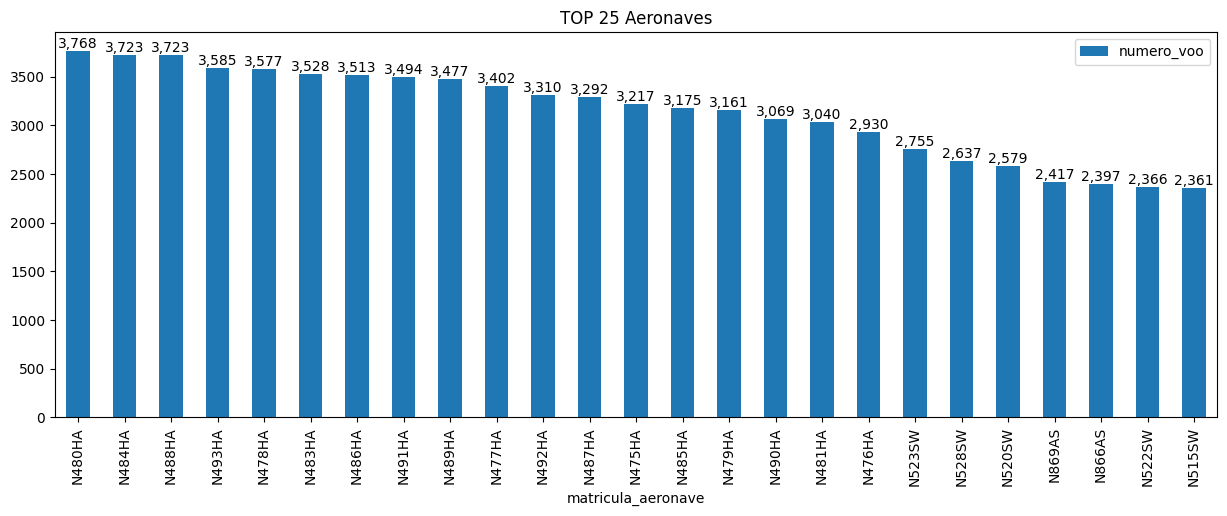

In [68]:
ax = df_flights.groupby(['matricula_aeronave'])['numero_voo'] \
               .count() \
               .sort_values(ascending=False).head(25) \
               .plot(kind='bar',
                     title='TOP 25 Aeronaves',
                     legend=True,
                     figsize=(15,5)
                     )

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 0),
                textcoords='offset points')


[Text(0, 0, 'ATL'),
 Text(1, 0, 'ORD'),
 Text(2, 0, 'DFW'),
 Text(3, 0, 'DEN'),
 Text(4, 0, 'LAX'),
 Text(5, 0, 'SFO'),
 Text(6, 0, 'PHX'),
 Text(7, 0, 'IAH'),
 Text(8, 0, 'LAS'),
 Text(9, 0, 'MSP')]

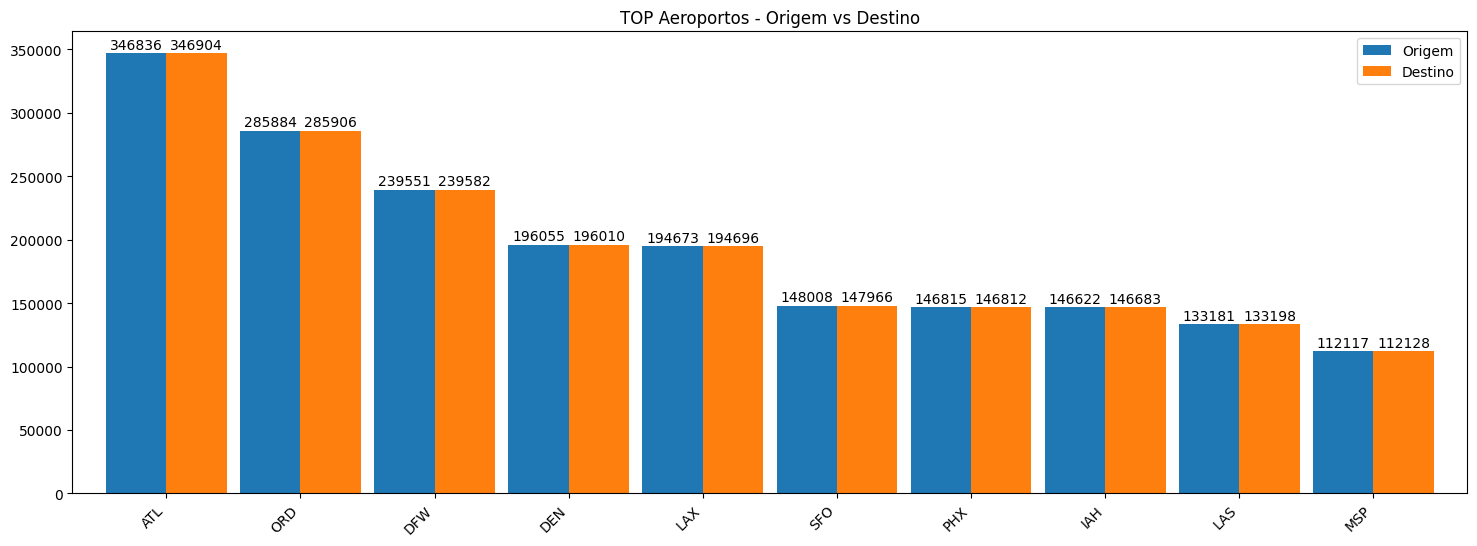

In [69]:
origem = df_flights['aeroporto_origem'].value_counts().rename('Origem')
destino = df_flights['aeroporto_destino'].value_counts().rename('Destino')

df_plot = (
    pd.concat([origem, destino], axis=1)
    .fillna(0)
    .sort_values('Destino', ascending=False)
    .head(10)
)


ax = df_plot.plot(kind='bar', figsize=(18,6), width = 0.9,
                  title='TOP Aeroportos - Origem vs Destino')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=1)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


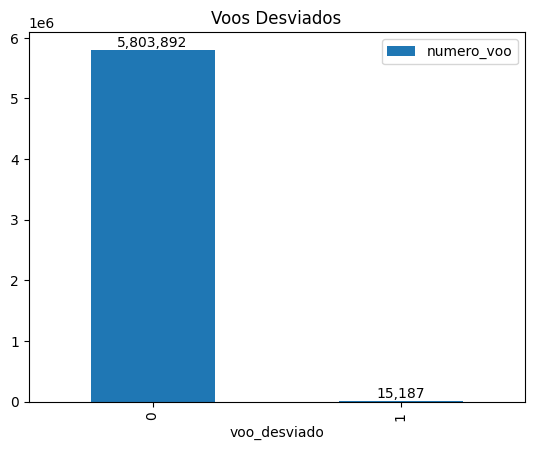

In [70]:
ax = df_flights.groupby(['voo_desviado'])['numero_voo'] \
               .count() \
               .sort_values(ascending=False) \
               .plot(kind='bar',
                     title='Voos Desviados',
                     legend=True)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 0),
                textcoords='offset points')


In [71]:
df_flights_modelo = df_flights.copy()

In [72]:
df_flights_modelo[df_flights_modelo['aeroporto_origem'] == 11433]

,ano,mes,dia,dia_da_semana,companhia_aerea,numero_voo,matricula_aeronave,aeroporto_origem,aeroporto_destino,partida_programada,horario_partida_real,atraso_partida,tempo_taxi_saida,decolagem_real,tempo_programado_voo,tempo_total_voo,tempo_no_ar,distancia,pouso_real,tempo_taxi_chegada,chegada_programada,horario_chegada_real,atraso_chegada,voo_desviado,voo_cancelado,status_voo,velocidade_media
4390917,2015,10,1,4,DL,1366,N684DA,11433,14492,1018,1014.0,-4.0,14.0,1028.0,98.0,98.0,81.0,501,1149.0,3.0,1156,1152.0,-4.0,0,0,pontual,5.112245
4390927,2015,10,1,4,EV,5027,N398CA,11433,13244,1020,1045.0,25.0,12.0,1057.0,117.0,104.0,90.0,610,1127.0,2.0,1117,1129.0,12.0,0,0,atrasado,5.213675
4390979,2015,10,1,4,DL,564,N891AT,11433,13930,1020,1018.0,-2.0,19.0,1037.0,76.0,71.0,46.0,235,1023.0,6.0,1036,1029.0,-7.0,0,0,pontual,3.092105
4391003,2015,10,1,4,EV,5581,N921EV,11433,15412,1022,1016.0,-6.0,19.0,1035.0,94.0,98.0,75.0,443,1150.0,4.0,1156,1154.0,-2.0,0,0,pontual,4.712766
4391087,2015,10,1,4,OO,4607,N659BR,11433,12884,1026,1019.0,-7.0,13.0,1032.0,44.0,41.0,23.0,100,1054.0,4.0,1107,1058.0,-9.0,0,0,pontual,2.272727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4848831,2015,10,30,5,DL,2793,N923DN,11433,13487,1000,959.0,-1.0,17.0,1016.0,104.0,110.0,89.0,528,1045.0,4.0,1044,1049.0,5.0,0,0,atrasado,5.076923
4848832,2015,10,30,5,DL,52,N917DN,11433,13487,1000,1002.0,2.0,19.0,1021.0,104.0,112.0,90.0,528,1051.0,3.0,1044,1054.0,10.0,0,0,atrasado,5.076923
4848959,2015,10,30,5,DL,379,N396DA,11433,12953,1005,1002.0,-3.0,23.0,1025.0,111.0,102.0,74.0,502,1139.0,5.0,1156,1144.0,-12.0,0,0,pontual,4.522523
4849027,2015,10,30,5,DL,1715,N904DA,11433,10397,1008,1009.0,1.0,17.0,1026.0,117.0,106.0,82.0,594,1148.0,7.0,1205,1155.0,-10.0,0,0,pontual,5.076923


In [73]:
df_flights_modelo[['aeroporto_origem','aeroporto_destino']] = \
df_flights_modelo[['aeroporto_origem','aeroporto_destino']].astype('string')


In [74]:
lb = LabelEncoder()

df_flights_modelo['companhia_aerea'] = lb.fit_transform(df_flights_modelo['companhia_aerea'])
df_flights_modelo['matricula_aeronave'] = lb.fit_transform(df_flights_modelo['matricula_aeronave'])
df_flights_modelo['aeroporto_origem'] = lb.fit_transform(df_flights_modelo['aeroporto_origem'])
df_flights_modelo['aeroporto_destino'] = lb.fit_transform(df_flights_modelo['aeroporto_destino'])

In [75]:

(df_flights_modelo.isna().sum() / df_flights_modelo.shape[0] * 100).sort_values(ascending = False)

ano                     0.0
mes                     0.0
dia                     0.0
dia_da_semana           0.0
companhia_aerea         0.0
numero_voo              0.0
matricula_aeronave      0.0
aeroporto_origem        0.0
aeroporto_destino       0.0
partida_programada      0.0
horario_partida_real    0.0
atraso_partida          0.0
tempo_taxi_saida        0.0
decolagem_real          0.0
tempo_programado_voo    0.0
tempo_total_voo         0.0
tempo_no_ar             0.0
distancia               0.0
pouso_real              0.0
tempo_taxi_chegada      0.0
chegada_programada      0.0
horario_chegada_real    0.0
atraso_chegada          0.0
voo_desviado            0.0
voo_cancelado           0.0
status_voo              0.0
velocidade_media        0.0
dtype: float64

In [76]:
df_flights_modelo.head(20)

,ano,mes,dia,dia_da_semana,companhia_aerea,numero_voo,matricula_aeronave,aeroporto_origem,aeroporto_destino,partida_programada,horario_partida_real,atraso_partida,tempo_taxi_saida,decolagem_real,tempo_programado_voo,tempo_total_voo,tempo_no_ar,distancia,pouso_real,tempo_taxi_chegada,chegada_programada,horario_chegada_real,atraso_chegada,voo_desviado,voo_cancelado,status_voo,velocidade_media
0,2015,1,1,4,1,98,1622,323,584,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,pontual,7.063415
1,2015,1,1,4,0,2336,1556,482,542,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,pontual,8.321429
2,2015,1,1,4,11,840,421,584,373,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,atrasado,8.027972
3,2015,1,1,4,0,258,1516,482,510,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,pontual,8.217544
4,2015,1,1,4,1,135,2131,583,324,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,pontual,6.161702
5,2015,1,1,4,3,806,1141,584,523,25,20.0,-5.0,18.0,38.0,217.0,230.0,206.0,1589,604.0,6.0,602,610.0,8.0,0,0,atrasado,7.322581
6,2015,1,1,4,8,612,2765,480,523,25,19.0,-6.0,11.0,30.0,181.0,170.0,154.0,1299,504.0,5.0,526,509.0,-17.0,0,0,pontual,7.176796
7,2015,1,1,4,11,2013,2410,482,373,30,44.0,14.0,13.0,57.0,273.0,249.0,228.0,2125,745.0,8.0,803,753.0,-10.0,0,0,pontual,7.783883
8,2015,1,1,4,0,1112,1561,584,393,30,19.0,-11.0,17.0,36.0,195.0,193.0,173.0,1464,529.0,3.0,545,532.0,-13.0,0,0,pontual,7.507692
9,2015,1,1,4,3,1173,3934,480,327,30,33.0,3.0,12.0,45.0,221.0,203.0,186.0,1747,651.0,5.0,711,656.0,-15.0,0,0,pontual,7.904977


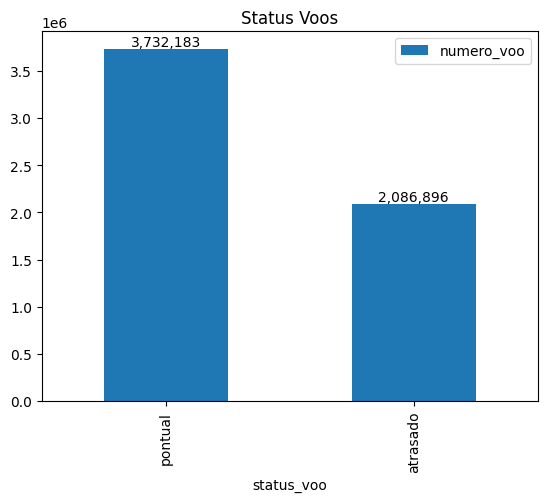

In [77]:
ax = df_flights_modelo.groupby(['status_voo'])['numero_voo'] \
               .count() \
               .sort_values(ascending=False) \
               .plot(kind='bar',
                     title='Status Voos',
                     legend=True)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom',
                xytext=(0, 0),
                textcoords='offset points')


In [78]:
target = df_flights_modelo['atraso_chegada']
predict = df_flights_modelo.drop(columns=[
    'atraso_chegada',
    'tempo_taxi_chegada',
    'horario_chegada_real',
    'tempo_total_voo',
    'voo_cancelado',
    'tempo_no_ar',
    'pouso_real',
    'status_voo',
    'numero_voo',
    'chegada_programada'
])


#target = target.map({'pontual': 0, 'atrasado': 1})



In [79]:
predict.columns

Index(['ano', 'mes', 'dia', 'dia_da_semana', 'companhia_aerea',
       'matricula_aeronave', 'aeroporto_origem', 'aeroporto_destino',
       'partida_programada', 'horario_partida_real', 'atraso_partida',
       'tempo_taxi_saida', 'decolagem_real', 'tempo_programado_voo',
       'distancia', 'voo_desviado', 'velocidade_media'],
      dtype='object')

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    predict,
    target,
    test_size=0.2,
    random_state=42  
)


In [81]:
model = LinearRegression()

In [82]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("reg", LinearRegression())
])

In [83]:
model.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('reg', LinearRegression())])

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 7.33089979090618
RMSE: 11.04515116775641
R2: 0.9202025242734053


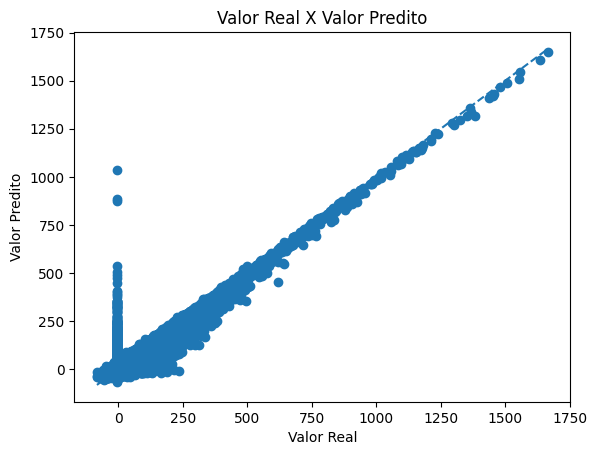

In [89]:
plt.scatter(y_test, y_pred)
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")
plt.title("Valor Real X Valor Predito")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--')

Text(0, 0.5, 'Resíduo')

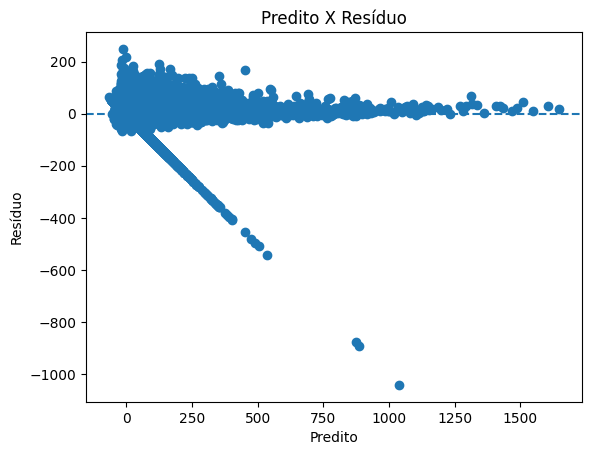

In [90]:
residuos = y_test - y_pred

plt.scatter(y_pred, residuos)
plt.axhline(y=0, linestyle='--')
plt.title("Predito X Resíduo")
plt.xlabel("Predito")
plt.ylabel("Resíduo")

((array([-4.85710199, -4.67839089, -4.58180331, ...,  4.58180331,
          4.67839089,  4.85710199], shape=(1163816,)),
  array([-1041.37272273,  -891.38094182,  -877.76132723, ...,
           205.64033483,   218.45560068,   248.69072862], shape=(1163816,))),
 (np.float64(10.133956602840302),
  np.float64(0.0027712007731242392),
  np.float64(0.9174986415056182)))

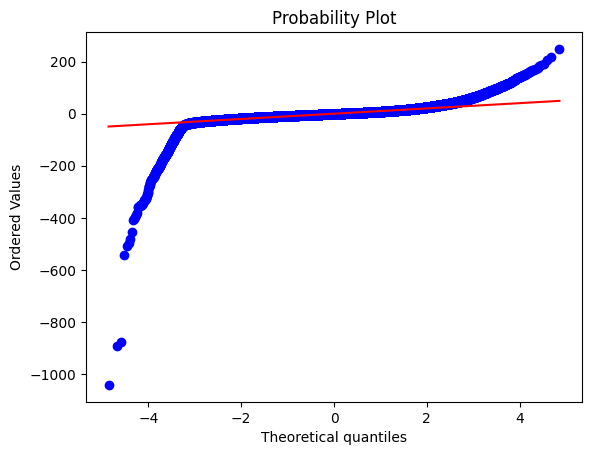

In [ ]:
import scipy.stats as stats

stats.probplot(residuos, dist="norm", plot=plt)